In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)


In [4]:
ball_positions = [x.get(1,[]) for x in ball_positions]
# Convert list -> pandas DF:
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

# Interpolate missing values:

df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()


In [7]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions["mid_y_rolling_mean"] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1, center = False).mean()

In [6]:
df_ball_positions.head(5)

,x1,y1,x2,y2
0,1503.737305,78.138153,1546.321777,196.779648
1,1503.741211,78.123894,1546.268188,196.867920
2,1503.590820,78.153145,1546.292847,197.225418
3,1503.577271,78.129135,1546.240845,197.248993
4,1503.594727,78.135132,1546.237427,197.184769


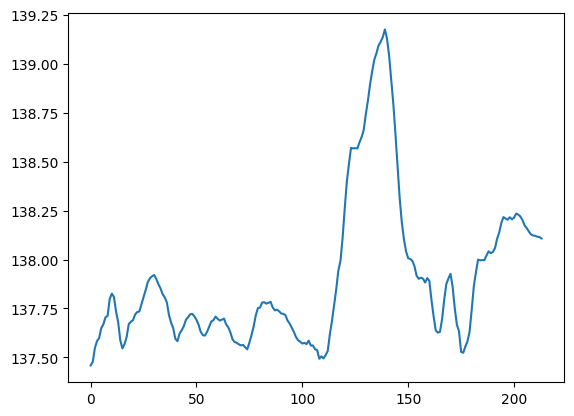

In [8]:
# Plotting the data:

plt.plot(df_ball_positions['mid_y_rolling_mean'])